# Toy Dataset Visualizer

This notebook loads one toy dataset and shows a compact summary.

Ways to choose the file:
- Set `CSV_PATH` in the second cell.
- Pass a `.csv` path as a notebook argument.
- Set the environment variable `TOY_DATASET_CSV`.

If none is provided, it falls back to `datasets/toy/linear_easy.csv`.

In [12]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


CSV_PATH = None
DEFAULT_CSV = "xor.csv"


def resolve_csv_path(csv_path=None, default=DEFAULT_CSV):
    if csv_path:
        return csv_path

    env_path = os.environ.get("TOY_DATASET_CSV")
    if env_path:
        return env_path

    cli_paths = [arg for arg in sys.argv[1:] if arg.lower().endswith(".csv")]
    if cli_paths:
        return cli_paths[0]

    return default


def read_dataset(csv_path):
    if str(csv_path).startswith("http://") or str(csv_path).startswith("https://"):
        return pd.read_csv(csv_path), Path(str(csv_path).split("/")[-1])

    candidates = [Path(csv_path), Path("datasets/toy") / csv_path]
    for candidate in candidates:
        if candidate.exists():
            return pd.read_csv(candidate), candidate

    return pd.read_csv(csv_path), Path(csv_path)


In [13]:
csv_path = resolve_csv_path(CSV_PATH)
df, resolved_path = read_dataset(csv_path)

print(f"Dataset file: {resolved_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print("\nClass balance:")
print(df["y"].value_counts().sort_index())
print("\nFeature summary:")
print(df[["x1", "x2"]].describe().round(3))
print("\nClass centroids:")
print(df.groupby("y")[["x1", "x2"]].mean().round(3))
print("\nCorrelation matrix:")
print(df[["x1", "x2", "y"]].corr().round(3))
df.head()

Dataset file: xor.csv
Rows: 200
Columns: ['x1', 'x2', 'y']

Class balance:
y
0    100
1    100
Name: count, dtype: int64

Feature summary:
            x1       x2
count  200.000  200.000
mean     0.042   -0.009
std      1.582    1.573
min     -2.503   -2.476
25%     -1.448   -1.583
50%      0.214   -0.049
75%      1.550    1.521
max      2.473    2.831

Class centroids:
      x1     x2
y              
0 -0.037 -0.001
1  0.122 -0.017

Correlation matrix:
       x1     x2      y
x1  1.000  0.002  0.050
x2  0.002  1.000 -0.005
y   0.050 -0.005  1.000


,x1,x2,y
0,-1.053093,1.520626,1
1,-2.050291,-1.273654,0
2,-1.526280,-1.051173,0
3,1.967452,-2.040037,1
4,1.644051,-2.190016,1


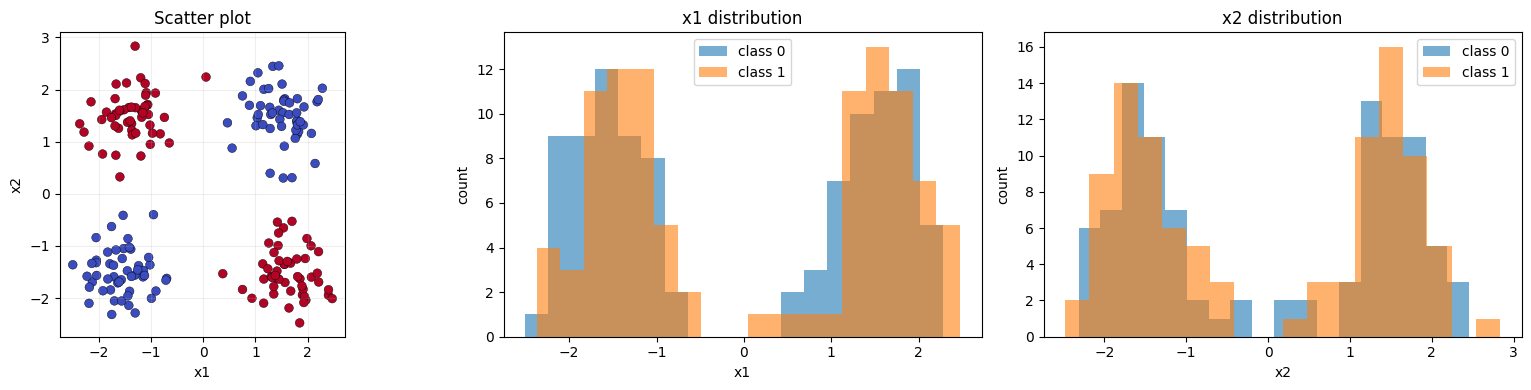

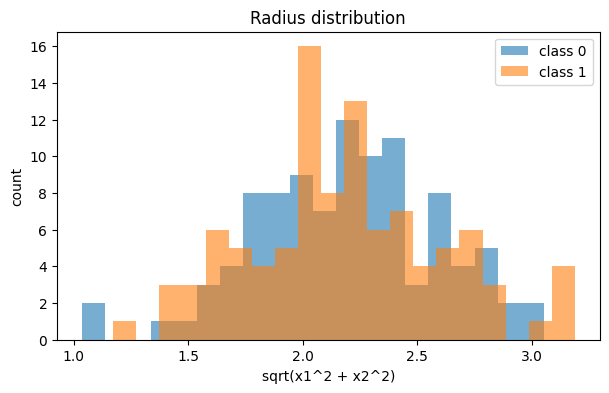

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df["x1"], df["x2"], c=df["y"], cmap="coolwarm", s=40, edgecolor="k", linewidth=0.3)
axes[0].set_title("Scatter plot")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(alpha=0.2)

for label in sorted(df["y"].unique()):
    subset = df[df["y"] == label]
    axes[1].hist(subset["x1"], bins=18, alpha=0.6, label=f"class {label}")
    axes[2].hist(subset["x2"], bins=18, alpha=0.6, label=f"class {label}")

axes[1].set_title("x1 distribution")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("count")
axes[1].legend()

axes[2].set_title("x2 distribution")
axes[2].set_xlabel("x2")
axes[2].set_ylabel("count")
axes[2].legend()

plt.tight_layout()
plt.show()

radius = np.sqrt(df["x1"] ** 2 + df["x2"] ** 2)
fig, ax = plt.subplots(figsize=(7, 4))
for label in sorted(df["y"].unique()):
    ax.hist(radius[df["y"] == label], bins=20, alpha=0.6, label=f"class {label}")
ax.set_title("Radius distribution")
ax.set_xlabel("sqrt(x1^2 + x2^2)")
ax.set_ylabel("count")
ax.legend()
plt.show()
